# **Processamento Digital de Sinais — 1ª Avaliação**



In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Todos os gráficos são salvos nesta pasta (criada se não existir)
IMAGES_DIR = 'images'
os.makedirs(IMAGES_DIR, exist_ok=True)

## Questão 1

### a) Sinal original — verificação do período $N = 5$

$\dfrac{12\pi}{5}N = 2\pi r \Rightarrow N = \dfrac{5r}{6}$, menor $r$ inteiro é $r=6 \Rightarrow N = 5$.

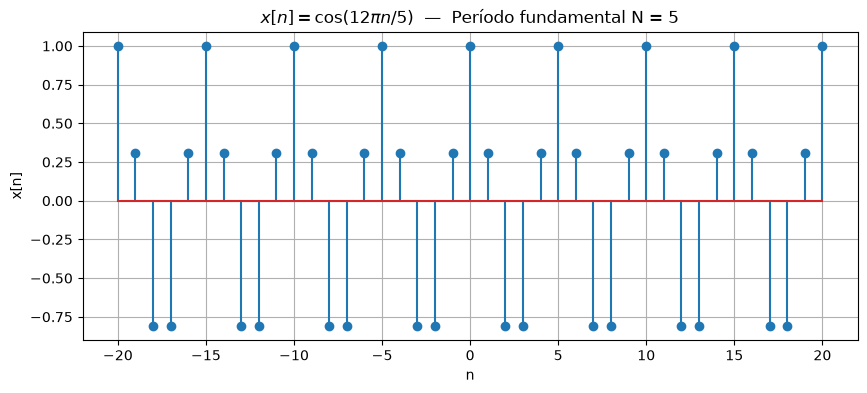

In [3]:
n = np.arange(-20, 21)
x = np.cos((12*np.pi/5)*n)

plt.figure(figsize=(10, 4))
plt.stem(n, x)
plt.xlabel('n')
plt.ylabel('x[n]')
plt.title(r'$x[n] = \cos(12\pi n / 5)$  —  Período fundamental N = 5')
plt.grid(True)
plt.savefig(os.path.join(IMAGES_DIR, 'grafico_1a.png'), dpi=150, bbox_inches='tight')
plt.show()

### b) Efeito da multiplicação da frequência no período

**Frequência × 2:** $\omega_0' = \dfrac{24\pi}{5}$ → $N = \dfrac{5r}{12}$, menor $r=12 \Rightarrow N = 5$ (o período **não muda**).

**Frequência × 5:** $\omega_0'' = 12\pi$ → $N = \dfrac{r}{6}$, menor $r=6 \Rightarrow N = 1$ (sinal vira **constante**, pois $12\pi n$ é sempre múltiplo de $2\pi$).

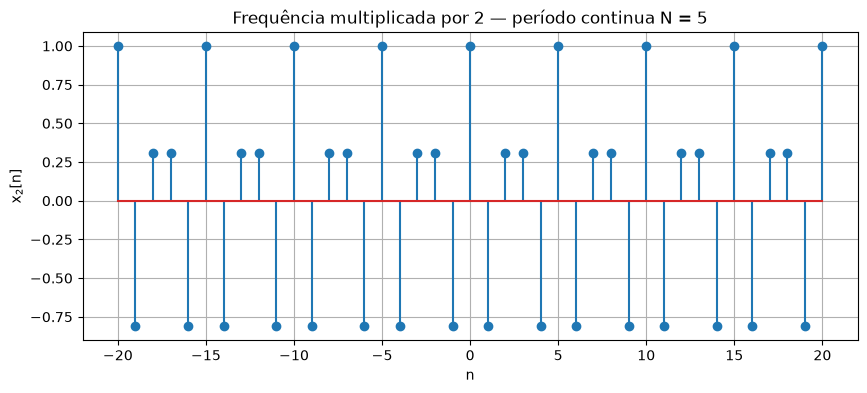

In [4]:
n = np.arange(-20, 21)

x2 = np.cos(2*(12*np.pi/5)*n)   # frequência x2

plt.figure(figsize=(10, 4))
plt.stem(n, x2)
plt.xlabel('n')
plt.ylabel('x$_2$[n]')
plt.title('Frequência multiplicada por 2 — período continua N = 5')
plt.grid(True)
plt.savefig(os.path.join(IMAGES_DIR, 'grafico_1b_x2.png'), dpi=150, bbox_inches='tight')
plt.show()

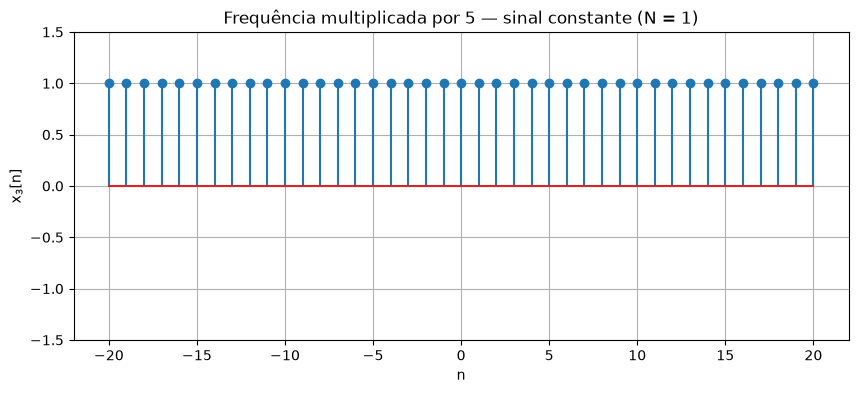

In [5]:
x3 = np.cos(5*(12*np.pi/5)*n)   # frequência x5

plt.figure(figsize=(10, 4))
plt.stem(n, x3)
plt.xlabel('n')
plt.ylabel('x$_3$[n]')
plt.title('Frequência multiplicada por 5 — sinal constante (N = 1)')
plt.grid(True)
plt.ylim(-1.5, 1.5)
plt.savefig(os.path.join(IMAGES_DIR, 'grafico_1b_x5.png'), dpi=150, bbox_inches='tight')
plt.show()

## Questão 2

Implementação da função `Deslocamento_Tempo(x, n, n0)`, que retorna $y[n] = x[n - n_0]$. A função funciona para qualquer vetor $x$, vetor de índices $n$ e escalar $n_0$ (positivo, negativo ou nulo).

In [6]:
def Deslocamento_Tempo(x, n, n0):
    """
    Retorna y tal que y[n] = x[n - n0], usando o MESMO vetor de indices n.
    Para cada indice n[i], busca o valor de x no indice (n[i] - n0);
    se esse indice nao existir no dominio original de x, preenche com 0.
    x  : vetor com as amostras do sinal
    n  : vetor de indices correspondente a x
    n0 : escalar com o deslocamento (n0 > 0: atraso, n0 < 0: avanco)
    """
    x = np.asarray(x)
    n = np.asarray(n)
    y = np.zeros_like(x, dtype=float)
    for i, ni in enumerate(n):
        alvo = ni - n0                
        pos = np.where(n == alvo)[0]
        if pos.size > 0:
            y[i] = x[pos[0]]
        else:
            y[i] = 0                 
    return y

### Exemplo

Sinal de exemplo: $n \in [-3, 5]$ e $x[n]$ um pulso triangular, com $n_0 = 3$ (atraso de 3 amostras). Como $y[n] = x[n-n_0]$ é calculado internamente pela função (buscando o valor de $x$ no índice $n-n_0$ e preenchendo com zero fora do domínio original), $x$ e $y$ já ficam definidos sobre o **mesmo** vetor de índices $n$, podendo ser plotados diretamente no mesmo eixo.

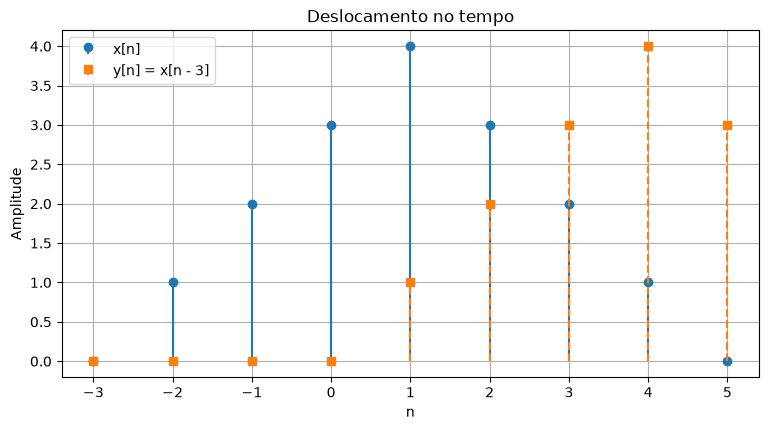

In [7]:
n = np.arange(-3, 6)
x = np.array([0, 1, 2, 3, 4, 3, 2, 1, 0])
n0 = 3
y = Deslocamento_Tempo(x, n, n0)

plt.figure(figsize=(9, 4.5))
plt.stem(n, x, linefmt='C0-', markerfmt='C0o', basefmt=' ', label='x[n]')
plt.stem(n, y, linefmt='C1--', markerfmt='C1s', basefmt=' ', label=f'y[n] = x[n - {n0}]')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.title('Deslocamento no tempo')
plt.grid(True)
plt.legend()
plt.savefig(os.path.join(IMAGES_DIR, 'grafico_2.png'), dpi=150, bbox_inches='tight')
plt.show()

## Questão 3

Para um sistema linear e invariante no tempo, a saída é a convolução entre a entrada $x[n]$ e a resposta ao impulso $h[n]$:

$$y[n]=(x*h)[n]=\sum_{k=-\infty}^{\infty}x[k]h[n-k].$$

Como os sinais são causais, $x[n]=h[n]=0$ para $n<0$, e o somatório se reduz a

$$y[n]=\sum_{k=0}^{n}x[k]h[n-k].$$

Se `x` possui $N_x$ amostras e `h` possui $N_h$ amostras, a saída completa possui $N_x+N_h-1$ amostras. A implementação calcula diretamente cada produto $x[k]h[m]$ e o acumula em $y[k+m]$, sem usar funções prontas de convolução.

In [8]:
def Convolucao(x, h):
    """Calcula a convolução completa de dois sinais causais sem np.convolve."""
    x = np.asarray(x)
    h = np.asarray(h)

    if x.ndim != 1 or h.ndim != 1:
        raise ValueError("x e h devem ser vetores unidimensionais.")
    if x.size == 0 or h.size == 0:
        raise ValueError("x e h não podem ser vetores vazios.")

    tipo = np.result_type(x.dtype, h.dtype)
    y = np.zeros(x.size + h.size - 1, dtype=tipo)

    for k in range(x.size):
        for m in range(h.size):
            y[k + m] += x[k] * h[m]

    return y

### Exemplo

Para $x[n]=\{1, 2 ,3\}$ e $h[n]=\{1,0{,}5\}$, com ambos começando em $n=0$, espera-se $y[n]=\{1; 2{,}5; 4; 1{,}5\}$.

In [9]:
x_exemplo = np.array([1, 2, 3])
h_exemplo = np.array([1, 0.5])
y_exemplo = Convolucao(x_exemplo, h_exemplo)

print("x[n] =", x_exemplo)
print("h[n] =", h_exemplo)
print("y[n] =", y_exemplo)

x[n] = [1 2 3]
h[n] = [1.  0.5]
y[n] = [1.  2.5 4.  1.5]


## Questão 4

A equação dada pode ser escrita como

$$y[n]=(1+r)y[n-1]+x[n].$$

Definindo $a=1+r$, a resposta ao impulso do sistema é $h[n]=a^n u[n]$. Como o aporte é constante e começa no primeiro mês, $x[n]=x\,u[n-1]$. A resposta total é a soma da resposta à condição inicial com a convolução dos aportes e da resposta ao impulso:

$$y[n]=a^ny_0+\sum_{k=1}^{n}x\,h[n-k]=a^ny_0+x\sum_{m=0}^{n-1}a^m.$$

Logo, para $r\neq0$,

$$\boxed{y[n]=y_0(1+r)^n+x\frac{(1+r)^n-1}{r}}.$$

Para $r=0$, a expressão se reduz a $\boxed{y[n]=y_0+nx}$. Assim, a implementação abaixo é uma solução fechada, e não uma iteração recursiva. A taxa deve ser informada na forma decimal (por exemplo, `0.01` para 1% ao mês).

In [10]:
def Investimento(y0, r, x, n):
    """Calcula o saldo após n meses por meio da solução fechada.

    O aporte x é realizado ao final de cada mês e r é uma taxa decimal.
    """
    if not isinstance(n, (int, np.integer)) or isinstance(n, (bool, np.bool_)):
        raise TypeError("n deve ser um número inteiro de meses.")
    if n < 0:
        raise ValueError("n não pode ser negativo.")
    if r <= -1:
        raise ValueError("r deve ser maior que -1.")

    if np.isclose(r, 0.0):
        return y0 + n*x

    fator = (1 + r)**n
    soma_aportes = np.expm1(n*np.log1p(r))/r
    return y0*fator + x*soma_aportes

### Exemplo

Investimento inicial de R$ 1.000,00, rentabilidade de 1% ao mês, aporte mensal de R$ 200,00 e prazo de 12 meses.

In [11]:
valor = Investimento(1000, 0.01, 200, 12)
print(f"Valor final do investimento: R$ {valor:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

Valor final do investimento: R$ 3.663,33


## Questão 5

Dada a equação de diferenças

$$y[n] = 0{,}038\,x[n-1] + 0{,}034\,x[n-2] + 1{,}63\,y[n-1] - 0{,}70\,y[n-2].$$

### a) Função de transferência $H(z)$

Aplicando a transformada $z$ (propriedade do deslocamento, $x[n-k]\leftrightarrow z^{-k}X(z)$) e agrupando os termos:

$$Y(z)\left(1 - 1{,}63\,z^{-1} + 0{,}70\,z^{-2}\right) = X(z)\left(0{,}038\,z^{-1} + 0{,}034\,z^{-2}\right).$$

Logo,

$$H(z) = \frac{Y(z)}{X(z)} = \frac{0{,}038\,z^{-1} + 0{,}034\,z^{-2}}{1 - 1{,}63\,z^{-1} + 0{,}70\,z^{-2}} = \frac{0{,}038\,z + 0{,}034}{z^{2} - 1{,}63\,z + 0{,}70}.$$

Os polos são $z = 0{,}815 \pm 0{,}189j$, com $|z| \approx 0{,}837 < 1$; portanto, o sistema é **estável** e a resposta em frequência existe.

### b) Resposta em frequência (magnitude e fase)

Fazendo $z = e^{j\omega}$:

$$H(e^{j\omega}) = \frac{0{,}038\,e^{-j\omega} + 0{,}034\,e^{-j2\omega}}{1 - 1{,}63\,e^{-j\omega} + 0{,}70\,e^{-j2\omega}}.$$

A **magnitude** é $\left|H(e^{j\omega})\right|$ e a **fase** é $\angle H(e^{j\omega})$, ambas funções de $\omega$.

### c) Gráficos da magnitude e da fase de $H(e^{j\omega})$

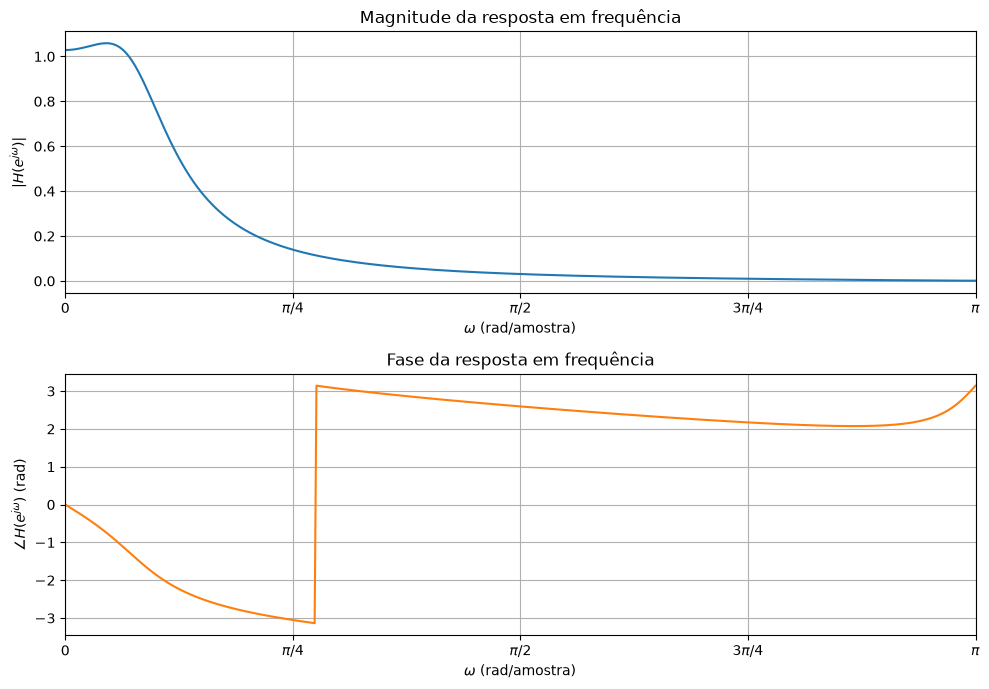

In [12]:
# Coeficientes da equação de diferenças
# y[n] = 0.038 x[n-1] + 0.034 x[n-2] + 1.63 y[n-1] - 0.70 y[n-2]
b = np.array([0.0, 0.038, 0.034])   # numerador: x[n], x[n-1], x[n-2]
a = np.array([1.0, -1.63, 0.70])    # denominador: y[n], y[n-1], y[n-2]

# Resposta em frequência H(e^{jw}) para w em [0, pi]
w = np.linspace(0, np.pi, 512)
ejw = np.exp(-1j * w)
num = b[0] + b[1]*ejw + b[2]*ejw**2
den = a[0] + a[1]*ejw + a[2]*ejw**2
H = num / den

mag = np.abs(H)
fase = np.angle(H)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))

ax1.plot(w, mag, 'C0')
ax1.set_xlabel(r'$\omega$ (rad/amostra)')
ax1.set_ylabel(r'$|H(e^{j\omega})|$')
ax1.set_title('Magnitude da resposta em frequência')
ax1.set_xlim(0, np.pi)
ax1.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax1.set_xticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
ax1.grid(True)

ax2.plot(w, fase, 'C1')
ax2.set_xlabel(r'$\omega$ (rad/amostra)')
ax2.set_ylabel(r'$\angle H(e^{j\omega})$ (rad)')
ax2.set_title('Fase da resposta em frequência')
ax2.set_xlim(0, np.pi)
ax2.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax2.set_xticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
ax2.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'grafico_5_mag_fase.png'), dpi=150, bbox_inches='tight')
plt.show()

### d) Saída para a entrada $x[n] = \cos\!\left(\dfrac{\pi}{4}n\right)$

Para um sistema LIT estável, a resposta em regime permanente a uma senoide $x[n]=\cos(\omega_0 n)$ é a mesma senoide, apenas escalada em amplitude por $\left|H(e^{j\omega_0})\right|$ e deslocada em fase por $\angle H(e^{j\omega_0})$:

$$y[n] = \left|H(e^{j\omega_0})\right|\,\cos\!\big(\omega_0 n + \angle H(e^{j\omega_0})\big).$$

Aqui $\omega_0 = \dfrac{\pi}{4}$. Avaliando $H(e^{j\omega})$ nesse ponto obtém-se

$$\left|H(e^{j\pi/4})\right| \approx 0{,}1393, \qquad \angle H(e^{j\pi/4}) \approx -3{,}051\ \text{rad}\ (\approx -174{,}8^\circ),$$

de modo que

$$\boxed{\,y[n] \approx 0{,}1393\,\cos\!\left(\dfrac{\pi}{4}n - 3{,}051\right).}$$

O sistema atenua fortemente essa frequência (ganho $\approx 0{,}14$) e introduz uma defasagem de quase meia volta.

### e) Gráfico de $x[n]$ e $y[n]$

|H(e^jpi/4)| = 0.1393
fase          = -3.0511 rad  (-174.81 graus)


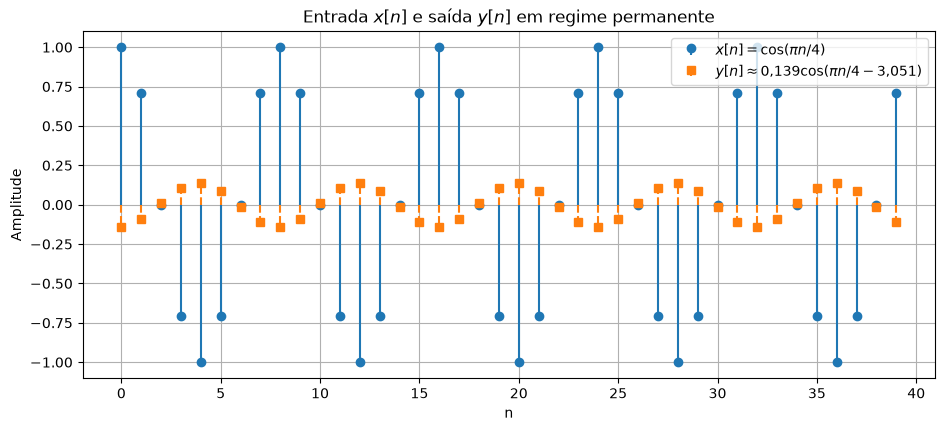

In [13]:
# Avaliação de H no ponto w0 = pi/4
w0 = np.pi/4
ejw0 = np.exp(-1j*w0)
H0 = (b[0] + b[1]*ejw0 + b[2]*ejw0**2) / (a[0] + a[1]*ejw0 + a[2]*ejw0**2)
A = np.abs(H0)          # ganho de amplitude
phi = np.angle(H0)      # defasagem (rad)

print(f"|H(e^jpi/4)| = {A:.4f}")
print(f"fase          = {phi:.4f} rad  ({np.degrees(phi):.2f} graus)")

# Sinais em regime permanente
n = np.arange(0, 40)
x = np.cos(w0*n)
y = A*np.cos(w0*n + phi)

plt.figure(figsize=(11, 4.5))
plt.stem(n, x, linefmt='C0-', markerfmt='C0o', basefmt=' ',
         label=r'$x[n]=\cos(\pi n/4)$')
plt.stem(n, y, linefmt='C1--', markerfmt='C1s', basefmt=' ',
         label=r'$y[n]\approx 0{,}139\cos(\pi n/4 - 3{,}051)$')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.title(r'Entrada $x[n]$ e saída $y[n]$ em regime permanente')
plt.grid(True)
plt.legend(loc='upper right')
plt.savefig(os.path.join(IMAGES_DIR, 'grafico_5_xy.png'), dpi=150, bbox_inches='tight')
plt.show()